### Student Information
Name: Robin Schroth

Student ID: 114751801

GitHub ID: robins114

---

### Instructions

### First Phase Submission

1. First: do the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) that considered as **phase 1 (from exercise 1 to exercise 15)**. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: follow the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** up **until phase 1**. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    -  Use [the new dataset](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/newdataset/Reddit-stock-sentiment.csv). The dataset contains a 16 columns including 'text' and 'label', with the sentiment labels being: 1.0 is positive, 0.0 is neutral and -1.0 is negative. You can simplify the dataset and use only the columns that you think are necessary.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.
    - Use this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output.


3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 10% of your grade.__
    - Generate meaningful **new data visualizations**. Refer to online resources and the Data Mining textbook for inspiration and ideas.
    


4. Fourth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__

You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (September 28th 11:59 pm, Sunday)__.

### Second Phase Submission

**You can keep the answer for phase 1 for easier running and update the phase 2 on the same page.**

1. First: Continue doing the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) for **phase 2, starting from Finding frequent patterns**. Use the same master(.ipynb) file. Answer from phase 1 will not be considered at this stage. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: Continue from first phase and do the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** for phase 2, starting from Finding frequent pattern. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    - Continue using this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output. Use the same new dataset as in phase 1.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.

3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 20% of your grade.__
    - Use this file to answer.
    - Generate **TF-IDF features** from the tokens of each text. This will generating a document matrix, however, the weights will be computed differently (using the TF-IDF value of each word per document as opposed to the word frequency).  Refer to this Scikit-learn [guide](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) .
    - Implement a simple **Naive Bayes classifier** that automatically classifies the records into their categories. Use both the TF-IDF features and word frequency features to build two seperate classifiers. Note that for the TF-IDF features you might need to use other type of NB classifier different than the one in the Master Notebook. Comment on the differences and when using augmentation with feature pattern.  Refer to this [article](https://hub.packtpub.com/implementing-3-naive-bayes-classifiers-in-scikit-learn/).


4. Fourth: In the lab, we applied each step really quickly just to illustrate how to work with your dataset. There are somethings that are not ideal or the most efficient/meaningful. Each dataset can be handled differently as well. What are those inefficent parts you noticed? How can you improve the Data preprocessing for these specific datasets? __This part is worth 10% of your grade.__


5. Fifth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__


You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (October 19th 11:59 pm, Sunday)__.

# Phase 1

In [35]:
!pip install numpy pandas matplotlib plotly nltk scikit-learn seaborn pami umap-learn
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
# test code for environment setup
import pandas as pd
import numpy as np
import nltk
nltk.download('punkt') # download the NLTK datasets
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
import plotly as py
import math
# If you get "ModuleNotFoundError: No module named 'PAMI'"
# run the following in a new Jupyter cell:
#!pip3 install PAMI
import PAMI
import umap

categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']
twenty_train = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=42)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
# Repo klonen
!git clone https://github.com/robins114/DM2025-Lab1-Exercise.git

# Ins Repo wechseln
%cd DM2025-Lab1-Exercise

# Jetzt klappt der Import
import helpers.data_mining_helpers as dmh

Cloning into 'DM2025-Lab1-Exercise'...
remote: Enumerating objects: 251, done.
remote: Counting objects: 100% (92/92), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 251 (delta 74), reused 52 (delta 52), pack-reused 159 (from 2)
Receiving objects: 100% (251/251), 29.08 MiB | 27.14 MiB/s, done.
Resolving deltas: 100% (120/120), done.
/content/DM2025-Lab1-Exercise


In [5]:
### Begin Assignment Here### Set up the environment
import pandas as pd
import numpy as np
import nltk
from sklearn.feature_extraction.text import CountVectorizer
import plotly as py
import math
import PAMI
import umap

import sys
print(sys.executable)  # path to Python
print(sys.version)     # python version

from google.colab import files #upload file to colab

uploaded = files.upload()
csv_filename = list(uploaded.keys())[0]

df = pd.read_csv(csv_filename)

print("Rownames:", df.columns.tolist())
print(df.head())

# DataFrame with text and labels
X = pd.DataFrame({
    'text': df['text'].astype(str),   # correct data structure
    'label': df['label'].astype(int)
})

# Map numeric labels (-1, 0, 1) to categories
label_map = {-1: 'negative', 0: 'neutral', 1: 'positive'}
X['category_name'] = X['label'].map(label_map)


print(X[['label', 'category_name']].head(10))

/usr/bin/python3
3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]


Saving Reddit-stock-sentiment.csv to Reddit-stock-sentiment.csv
Rownames: ['type', 'datetime', 'post_id', 'subreddit', 'title', 'author', 'url', 'upvotes', 'downvotes', 'upvote_ratio', 'text', 'subjectivity', 'polarity', 'sentiment', 'entities', 'label']
      type             datetime  post_id         subreddit  \
0  comment  2025-04-11 17:29:56  mmli62w    wallstreetbets   
1  comment   2025-04-12 1:12:19  mmnu7v9    wallstreetbets   
2  comment  2025-04-10 15:09:41  mmeevio       StockMarket   
3     post  2023-08-30 17:12:55  165kllm  stockstobuytoday   
4  comment  2025-04-11 14:48:05  mmkl6bw       StockMarket   

                                               title                author  \
0    Retardation is on the menu boys! WSB is so back          StickyTip420   
1  Retail giant TARGET has now declined for 10 co...  Comfortable-Dog-8437   
2  How do you feel about a sitting president maki...          Btankersly66   
3                              Who knows more? $VMAR        

In [8]:

# Define texts from the DataFrame
texts = X['text'].tolist()

# Exercise 1
for i in range(3):
    print(f"Example {i+1}")
    print("\n".join(texts[i].split("\n")))

Example 1
Calls on retards
Example 2
Stunt as in like why did they even make a big deal about starting it in the first place? No company should ever talk about politics ever.
Example 3
Seeing lots of red in the ticker.


In [7]:
import pandas as pd
# Texts should be a flat list of Strings
texts = [str(t) for t in texts]

# Create DataFrame
X = pd.DataFrame({
    'text': df['text'].astype(str),
    'label': df['label'].astype(int)
})

# Mapping von label (-1,0,1) to negative, neutral and positive
label_map = {-1: 'negative', 0: 'neutral', 1: 'positive'}
X['category_name'] = X['label'].map(label_map)

# Control
print(X[['label', 'category_name']].head(10))

   label category_name
0     -1      negative
1      0       neutral
2      0       neutral
3      1      positive
4     -1      negative
5      0       neutral
6     -1      negative
7      0       neutral
8      1      positive
9      1      positive


In [9]:
# Exercise 2

# Length of the dataset
print("Number of rows in the dataset:", len(X))

# First row from the dataset
print("First row:")
print(X.iloc[0])

# Last row from the dataset
print("Last row:")
print(X.iloc[-1])


Number of rows in the dataset: 847
First row:
text             Calls on retards
label                          -1
category_name            negative
Name: 0, dtype: object
Last row:
text             ![img](emote|t5_2th52|31224)
label                                       0
category_name                         neutral
Name: 846, dtype: object


In [10]:
# Exercise 3

# Every 10th record in the "positive" category
X_positive_sampled = X[X['category_name'] == 'positive'].iloc[::10].head(5)

print("Sample of every 10th 'positive' record (first 5):")
print(X_positive_sampled)

Sample of every 10th 'positive' record (first 5):
                                                  text  label category_name
3    Vision Marine Technologies Inc. is rewriting t...      1      positive
78   I think it’s gonna work itself out. I bought t...      1      positive
168  The obvious can also be refreshing from CNBC: ...      1      positive
219  Same. Back to break even after that last rip b...      1      positive
319  Etrade has a feed of news articles about how r...      1      positive


In [ ]:
# Repo klonen
!git clone https://github.com/robins114/DM2025-Lab1-Exercise.git

# Ins Repo wechseln
%cd DM2025-Lab1-Exercise

# Jetzt klappt der Import
import helpers.data_mining_helpers as dmh

Cloning into 'DM2025-Lab1-Exercise'...
remote: Enumerating objects: 245, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 245 (delta 74), reused 50 (delta 50), pack-reused 149 (from 1)
Receiving objects: 100% (245/245), 28.05 MiB | 22.53 MiB/s, done.
Resolving deltas: 100% (118/118), done.
/content/DM2025-Lab1-Exercise/DM2025-Lab1-Exercise/DM2025-Lab1-Exercise


In [11]:
# Exercise 4
#import helpers.data_mining_helpers_Homework as dmh
# Count missing values per row (axis=1)
# Uses the helper function check_missing_values from your dmh module
missing_per_row = X.isnull().apply(lambda row: dmh.check_missing_values(row), axis=1)

# For control: show missing values in the first 5 rows
print("Missing values per row (first 5 rows):")
print(missing_per_row.head(5))

Missing values per row (first 5 rows):
0    (The amoung of missing records is: , 0)
1    (The amoung of missing records is: , 0)
2    (The amoung of missing records is: , 0)
3    (The amoung of missing records is: , 0)
4    (The amoung of missing records is: , 0)
dtype: object


In [12]:
#Check for duplicates
sum(X.duplicated('text'))

23

In [13]:
# Dealing with duplicate data
X['datetime'] = df['datetime']
sum(X.duplicated('datetime'))

# only 5 datetimes are the same, so maybe 23 comments have been taken at a different time, but the user used the same text
# can be not a duplicate, as the time might be different

5

category_name
neutral     9
negative    8
positive    3
Name: count, dtype: int64


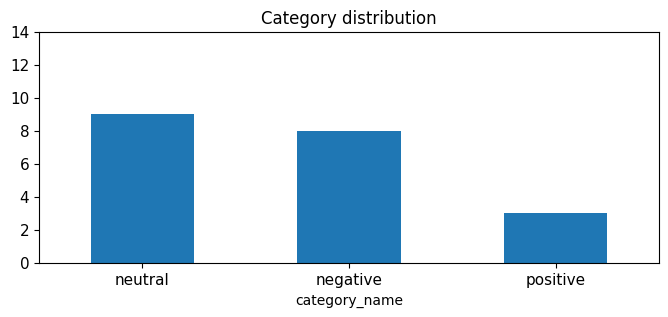

In [14]:
# Exercise 5 and 6, have the same answer as in the homework

# Exercise 7

# Data Preprocessing
import matplotlib.pyplot as plt
%matplotlib inline

# random selection of 20 samples
X_sample = X.sample(n=20, random_state=42)

print(X_sample.category_name.value_counts())

# Barchart
X_sample.category_name.value_counts().plot(
    kind='bar',
    title='Category distribution',
    ylim=[0, X_sample.category_name.value_counts().max()+5],
    rot=0,
    fontsize=11,
    figsize=(8,3)
)

plt.show()

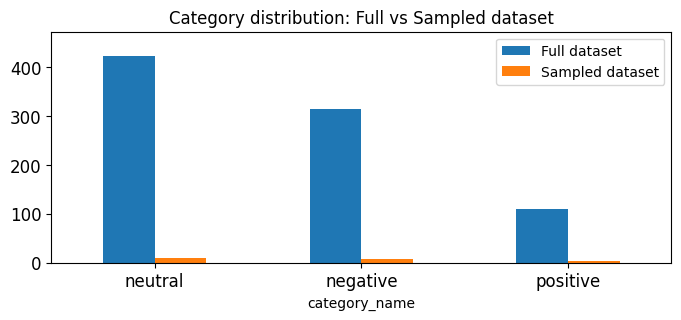

In [15]:
# Excercise 8

# Counts for both datasets
counts_df = pd.DataFrame({
    'Full dataset': X['category_name'].value_counts(),
    'Sampled dataset': X_sample['category_name'].value_counts()
})

# Define ylim as the highest value plus 10
y_max = max(counts_df.max()) + 50

# Plot
counts_df.plot(
    kind='bar',
    title='Category distribution: Full vs Sampled dataset',
    ylim=[0, y_max],
    rot=0,
    fontsize=12,
    figsize=(8,3)
)

plt.show()

In [17]:
import nltk # solve issues with nltk


nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [19]:

import nltk
nltk.download("punkt")
#import helpers.data_mining_helpers_Homework as dmh
import helpers.data_mining_helpers as dmh

# tokenize text into unigrams
X['unigrams'] = X['text'].apply(lambda x: dmh.tokenize_text(x))

# visual test
print(X[['text', 'unigrams']].head())
list(X[0:2]['unigrams'])

                                                text  \
0                                   Calls on retards   
1  Stunt as in like why did they even make a big ...   
2                  Seeing lots of red in the ticker.   
3  Vision Marine Technologies Inc. is rewriting t...   
4                           He didn’t say thank you.   

                                            unigrams  
0                               [Calls, on, retards]  
1  [Stunt, as, in, like, why, did, they, even, ma...  
2        [Seeing, lots, of, red, in, the, ticker, .]  
3  [Vision, Marine, Technologies, Inc., is, rewri...  
4               [He, didn, ’, t, say, thank, you, .]  


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


[['Calls', 'on', 'retards'],
 ['Stunt',
  'as',
  'in',
  'like',
  'why',
  'did',
  'they',
  'even',
  'make',
  'a',
  'big',
  'deal',
  'about',
  'starting',
  'it',
  'in',
  'the',
  'first',
  'place',
  '?',
  'No',
  'company',
  'should',
  'ever',
  'talk',
  'about',
  'politics',
  'ever',
  '.']]

In [20]:
from sklearn.feature_extraction.text import CountVectorizer

count_vect = CountVectorizer()

# transform text into document-term matrix
X_counts = count_vect.fit_transform(X['text'])

# visual test
print(X_counts[0])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3 stored elements and shape (1, 4346)>
  Coords	Values
  (0, 692)	1
  (0, 2706)	1
  (0, 3248)	1


In [21]:
#Exercise 9
analyze = count_vect.build_analyzer()
analyze(X.text[0])

['calls', 'on', 'retards']

In [22]:
X_counts.shape
count_vect.get_feature_names_out()[0:1]

array(['00'], dtype=object)

In [24]:
# Excercise 10

# Get first row
first_row = X_counts[0]

# Get indices with value 1
indices_with_1 = first_row.nonzero()[1]

# Vocabulary
vocab = count_vect.get_feature_names_out()
words_with_1 = vocab[indices_with_1]

# Print results
print("Positions of 1s in first row:", indices_with_1)
print("Corresponding words:", words_with_1)

Positions of 1s in first row: [ 692 2706 3248]
Corresponding words: ['calls' 'on' 'retards']


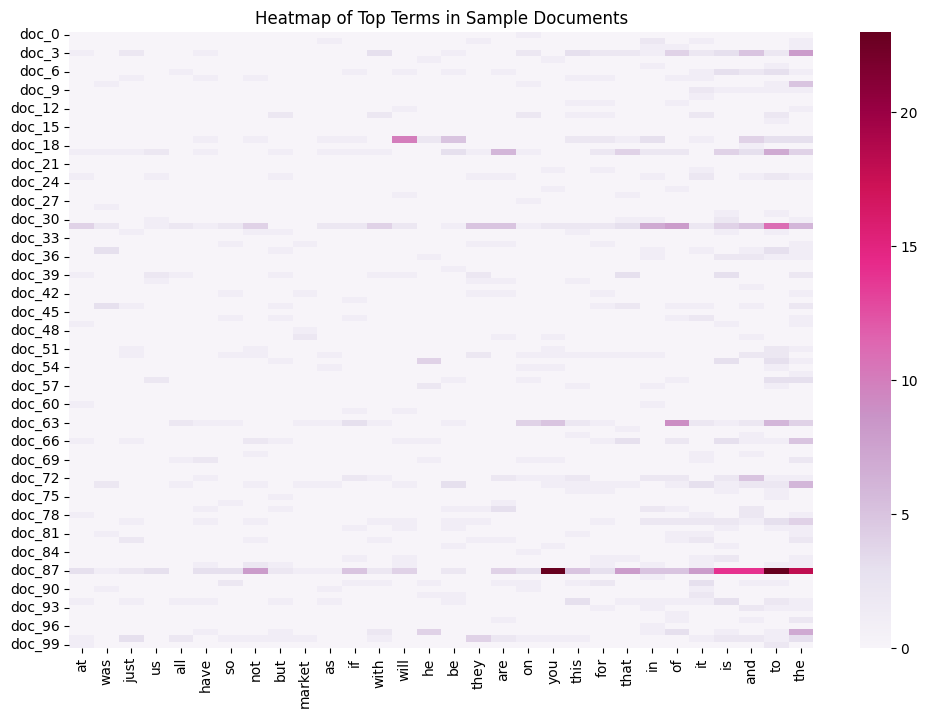

In [25]:
# Exercise 11

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Parameters
num_docs = 100   # term-document sample
num_terms = 30   # top n terms by frequency

# Term frequencies
term_sums = np.array(X_counts.sum(axis=0)).flatten()
top_indices = term_sums.argsort()[-num_terms:]  # indices of top-N terms

# Rename the axes
plot_x = count_vect.get_feature_names_out()[top_indices]  # top term names
plot_y = ["doc_"+str(i) for i in list(X.index)[0:num_docs]]  # document labels

# Create submatrix for the heatmap
plot_z = X_counts[0:num_docs, top_indices].toarray()

# Create DataFrame for heatmap
df_todraw = pd.DataFrame(plot_z, columns=plot_x, index=plot_y)

# Plot
plt.subplots(figsize=(12, 8))
ax = sns.heatmap(df_todraw,
                 cmap="PuRd",
                 vmin=0, vmax=np.max(plot_z),
                 annot=False)
plt.title("Heatmap of Top Terms in Sample Documents")
plt.show()


In [26]:
# Exercise 12

import plotly.express as px

# Compute term frequencies
term_frequencies = np.array(X_counts.sum(axis=0)).flatten()

# Select top 300 terms
top_n = 300
top_indices = term_frequencies.argsort()[-top_n:][::-1]

terms_to_plot = count_vect.get_feature_names_out()[top_indices]
freqs_to_plot = term_frequencies[top_indices]

# Create DataFrame
df_plotly = pd.DataFrame({
    'Term': terms_to_plot,
    'Frequency': freqs_to_plot
})

# bar chart
fig = px.bar(df_plotly,
             x='Term', y='Frequency',
             title=f'Top {top_n} Terms in Entire Corpus',
             text='Frequency',
             labels={'Frequency':'Count', 'Term':'Word'})

# Layout based on the homework
fig.update_traces(marker_color='orange', textposition='outside')
fig.update_layout(xaxis_tickangle=-90, width=1200, height=600)
fig.show()


In [27]:
# Exercise 13

# term frequencies
term_frequencies = np.array(X_counts.sum(axis=0)).flatten()

# select the top 50 terms
top_n = 50
top_indices = np.argsort(term_frequencies)[-top_n:][::-1]
top_terms = count_vect.get_feature_names_out()[top_indices]
top_counts = term_frequencies[top_indices]

# DataFrame
df_top = pd.DataFrame({
    'Term': top_terms,
    'Frequency': top_counts
})

# Bar chart
fig = px.bar(df_top, x='Term', y='Frequency',
             title=f'Top {top_n} Terms in Entire Corpus',
             text='Frequency',
             labels={'Frequency':'Count', 'Term':'Word'})

# Layout based on the homework
fig.update_traces(marker_color='orange', textposition='outside')
fig.update_layout(xaxis_tickangle=-45, width=900, height=500)
fig.show()


In [28]:
#Exercise 14

# Ter, frequencies
term_frequencies = np.array(X_counts.sum(axis=0)).flatten()

# top 50 terms
top_n = 50
top_indices = np.argsort(term_frequencies)[-top_n:]
top_terms = count_vect.get_feature_names_out()[top_indices]
top_counts = term_frequencies[top_indices]

# DataFrame
df_top = pd.DataFrame({
    'Term': top_terms,
    'Frequency': top_counts
})

# decreasing frequency
df_top = df_top.sort_values(by='Frequency', ascending=False)

# Bar chart
fig = px.bar(df_top, x='Term', y='Frequency',
             title=f'Top {top_n} Terms in Entire Corpus (Sorted by Frequency)',
             text='Frequency',
             labels={'Frequency':'Count', 'Term':'Word'})

# Layout
fig.update_traces(marker_color='orange', textposition='outside')
fig.update_layout(xaxis_tickangle=-90, width=900, height=500)
fig.show()


/tmp/ipython-input-3419641105.py:19: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



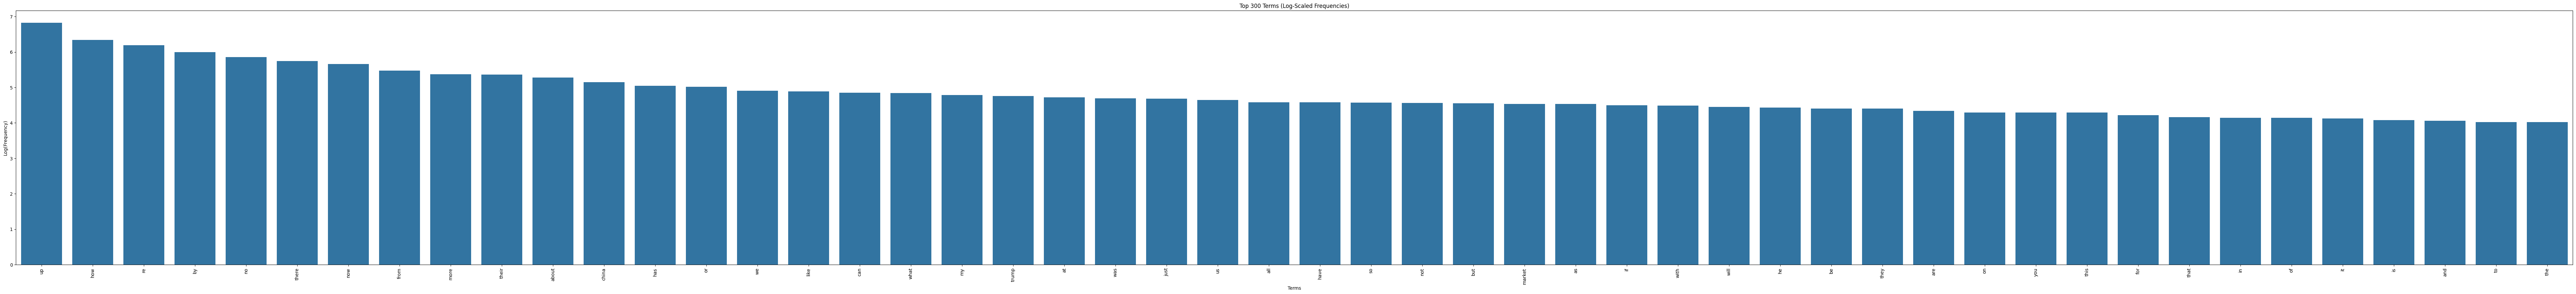

In [30]:
#Exercise 15 is the same

# Transform into log distribution

import math

# term frequencies
term_frequencies = np.array(X_counts.sum(axis=0)).flatten()

# Log scaling (add 1 to avoid undefined log(0))
term_frequencies_log = [math.log(i + 1) for i in term_frequencies]
top_idx = np.argsort(term_frequencies)[-top_n:][::-1]
top_counts_log = np.array(term_frequencies_log)[top_idx]


# Plot
plt.subplots(figsize=(100, 10))
g = sns.barplot(x=top_terms, y=top_counts_log)
g.set_xticklabels(top_terms, rotation=90)
g.set_title("Top 300 Terms (Log-Scaled Frequencies)")
g.set_ylabel("Log(Frequency)")
g.set_xlabel("Terms")
plt.show()


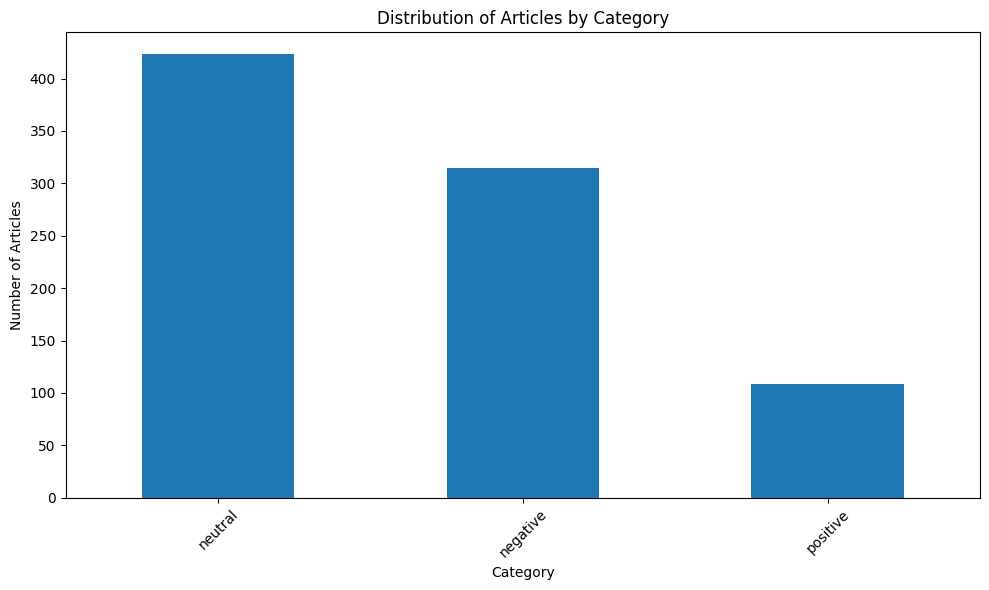

In [32]:
# 3. Step: Generate meaningful new data visualizations.

# Visualize the distribution of articles across different categories.
import matplotlib.pyplot as plt

# Count the occurrences of each category
category_counts = X['category_name'].value_counts()

# Bar chart
plt.figure(figsize=(10, 6))
category_counts.plot(kind='bar')
plt.title('Distribution of Articles by Category')
plt.xlabel('Category')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

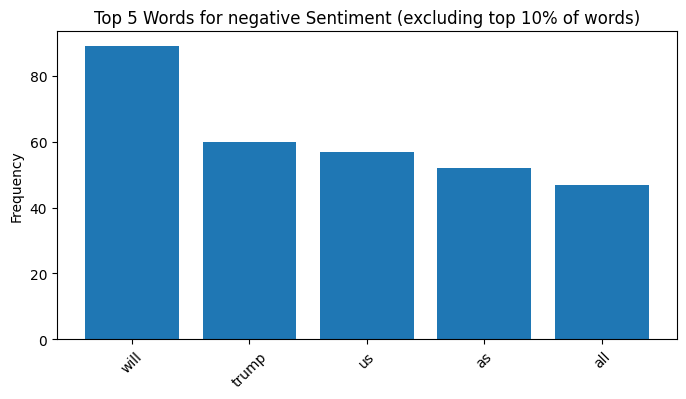

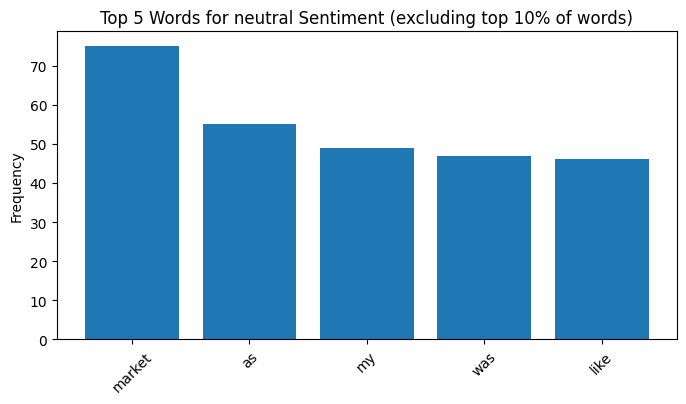

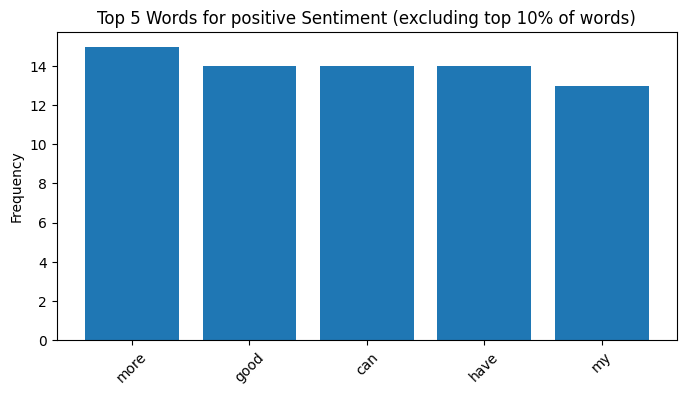

In [33]:
# Top Terms per Sentiment Category (excluding the overall top 10% of words, to mostly avoid frequently used words without any sentiment indication)

top_n = 5

# 10%-Filter
global_vectorizer = CountVectorizer(max_df=0.1)
global_vectorizer.fit(X['text'])

for label, name in zip([-1, 0, 1], ['negative', 'neutral', 'positive']):
    subset = X[X['label'] == label]

    # same filter for every category
    counts = np.array(global_vectorizer.transform(subset['text']).sum(axis=0)).flatten()
    vocab = global_vectorizer.get_feature_names_out()

    # Index of Top-N-words
    top_indices = counts.argsort()[-top_n:][::-1]

    top_words = vocab[top_indices]
    top_counts = counts[top_indices]

    plt.figure(figsize=(8,4))
    plt.bar(top_words, top_counts)
    plt.title(f'Top {top_n} Words for {name} Sentiment (excluding top 10% of words)')
    plt.xticks(rotation=45)
    plt.ylabel('Frequency')
    plt.show()

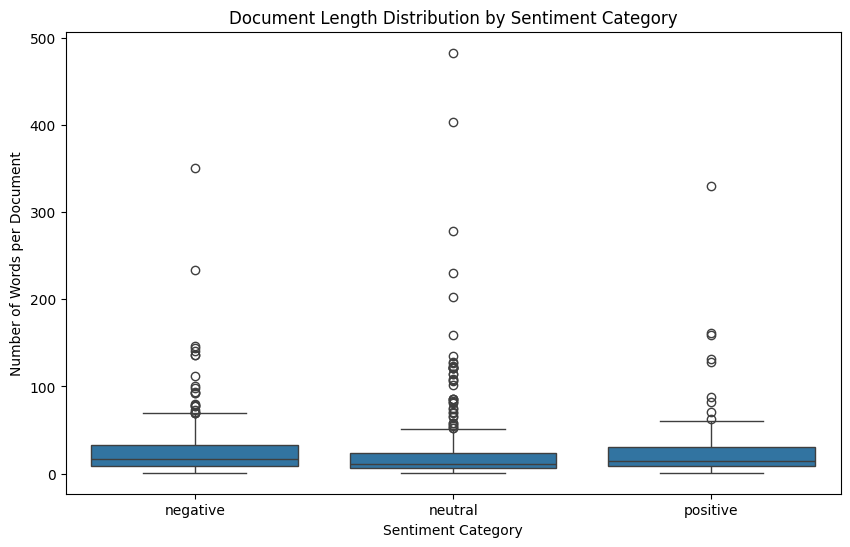

In [34]:
# Category-wise Document Length Distribution (Boxplot)

import matplotlib.pyplot as plt
import seaborn as sns

# Compute text lengths (Anzahl Wörter pro Dokument)
X['text_length'] = X['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10,6))
sns.boxplot(
    x='category_name',
    y='text_length',
    data=X,
   # palette='pastel'
)

plt.title('Document Length Distribution by Sentiment Category')
plt.ylabel('Number of Words per Document')
plt.xlabel('Sentiment Category')
plt.show()

# Phase 2

In [ ]:
### Begin Assignment Here